In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

In [2]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
N_chamber = 10
x_scale = 10000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

In [3]:
# Random distribution
np.random.seed(0)

# Set limits of characteristic size of chamber
R_min = 500
R_max = 500
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# List generation of chamber characteristics
x_nodes = 0.0 * np.random.rand(N_chamber)
y_nodes = 0.0 * np.random.rand(N_chamber)
z_nodes = np.linspace(0.0, z_scale, N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Characteristic node separation distance
node_sep = z_scale/(N_chamber - 1)

# Symmetric distance matrix
d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
     + (y_nodes - y_nodes[:,np.newaxis]) ** 2
     + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=0.0,
                    p0=0.0,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

In [4]:
# Set up for timestepping later
global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                   r_hydr=r_hydr, mu0=mu0, 
                                   rho0=2500, K_f=K_f, Nr=50,
                                   dpdx_crit=1e3,
                                   dpdx_threshold_scale=1e2,
                                   R_outer_ratio=20,
                                   max_edge_dist=1.1*node_sep)

# Source term due to mass injection at node 0
f_inj = global_sys.create_single_mass_injection_source(1.0)
# Source term due to eruption at node -1
f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)

In [8]:
t_vec = np.linspace(0, 5e11, 10000)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)

In [ ]:
# Effective storage?

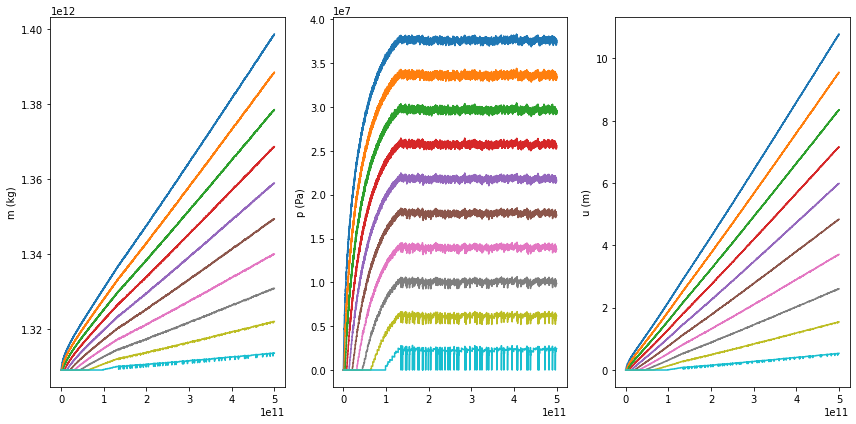

In [9]:
m, p, u = global_sys.compute_m_p_u(q_out)
fig, ax = plt.subplots(1, 3, figsize=(12,6))

max_plot_index = -1
ax[0].plot(t_vec[:max_plot_index], m[:max_plot_index])
ax[1].plot(t_vec[:max_plot_index], p[:max_plot_index])
ax[2].plot(t_vec[:max_plot_index], u[:max_plot_index])

ax[0].set_ylabel("m (kg)")
ax[1].set_ylabel("p (Pa)")
ax[2].set_ylabel("u (m)")
fig.tight_layout()

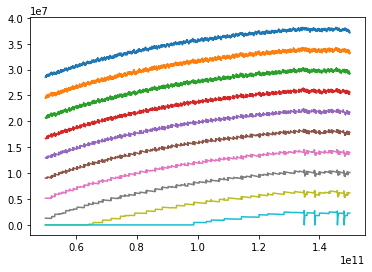

In [10]:
max_plot_index = 1000
plt.plot(t_vec[1000:3000], p[1000:3000])


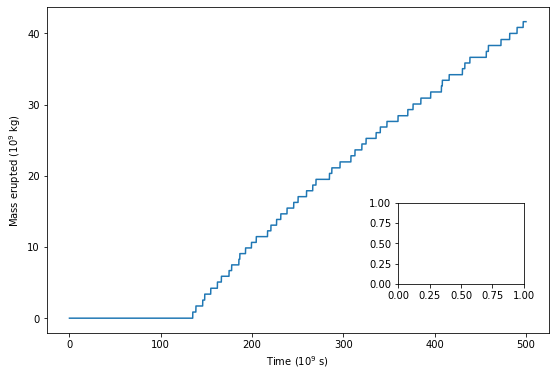

In [11]:
plt.figure(figsize=(9,6))
plt.plot(t_vec/1e9, m_erupted_out/1e9)
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Mass erupted ($10^9$ kg)")

axin1 = plt.gca().inset_axes([0.7, 0.15, 0.25, 0.25])

# axin2 = plt.gca().inset_axes([5, 7, 2.3, 2.3], transform=ax.transData)

(60.0, 70.0)

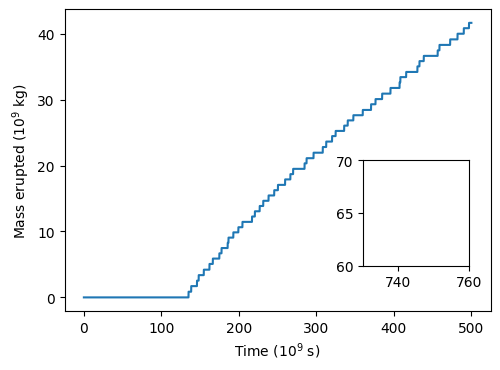

In [12]:
plt.figure(figsize=(5.5,4), dpi=100)
plt.plot(t_vec/1e9, m_erupted_out/1e9)
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Mass erupted ($10^9$ kg)")

inset_axes = plt.gca().inset_axes([0.7, 0.15, 0.25, 0.35])
inset_axes.plot(t_vec/1e9, m_erupted_out/1e9, '.-')
inset_axes.set_xlim(730,760)
inset_axes.set_ylim(60,70)


Text(0, 0.5, '$\\Delta t/dt$')

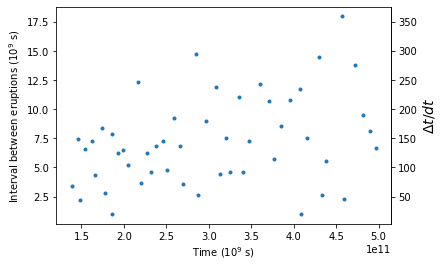

In [13]:

# Binarize eruption rates
is_erupting = np.diff(m_erupted_out) > 0
# Interval-centered times
t_vec_centered = 0.5*(t_vec[1:] + t_vec[:-1])

# Time picks for eruptions
t_eruptions = t_vec_centered[is_erupting]
# Inter-eruption intervals
t_eruption_intervals = np.diff(t_eruptions)

plt.plot(t_eruptions[1:], t_eruption_intervals/1e9, '.')
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Interval between eruptions ($10^9$ s)")
# Estimate dpdt
dt = t_vec[1] - t_vec[0]
ax2y = plt.gca().secondary_yaxis('right', functions=(
  lambda t: 1e9 * t / dt,
  lambda tau: tau * dt / 1e9))
ax2y.set_ylabel('$\Delta t/dt$', fontsize=14)

#### Melt focusing

#### Testing

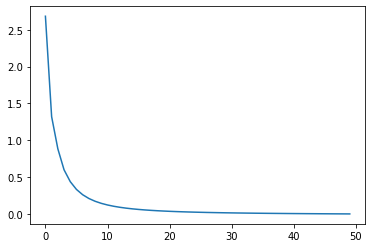

In [27]:
# Pick sample q for testing
q = q_out[-1,:]
# Extract state vector q for top node
q_loc = q[(global_sys.num_blocks-1) * global_sys.block_size:
          global_sys.num_blocks * global_sys.block_size]
# Compute max discharge from pressure
top_node = global_sys.nodes[-1]
# Compute displacement field for top node
u = (top_node.H @ q_loc + top_node.k.ravel())
plt.plot(u)

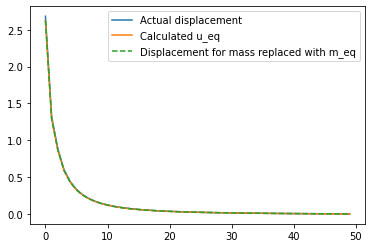

In [28]:
''' Compute displacement field after instantaneous depressurization to p0
and associated residual mass.'''

# Outer product matrix representing effect of mass on bdry displacement
outer = scipy.sparse.lil_matrix((global_sys.Nr, global_sys.Nr,))
outer[:,0] = 3 * top_node.m0 / top_node.R0 * top_node.H[:,global_sys.data_slice["mass"]]
# Compute operator q -> m_equilibrium, with the form m_eq = H_mod @ q + k_mod
H_mod = scipy.sparse.linalg.spsolve_triangular(
  scipy.sparse.eye(global_sys.Nr, global_sys.Nr) - outer,
  top_node.H.todense(),
  lower=True)
# Compute modified k
k_mod =  scipy.sparse.linalg.spsolve_triangular(
  scipy.sparse.eye(global_sys.Nr, global_sys.Nr) - outer,
  top_node.k,
  lower=True)
# Move dependence on mass in input q to dependence on m0
k_mod += H_mod[:, global_sys.data_slice["mass"]] * top_node.m0
H_mod[:, global_sys.data_slice["mass"]] = 0
# Finalize types of H, k
H_mod = scipy.sparse.csr_matrix(H_mod)
# k_mod = k_mod.toarray()

plt.plot((top_node.H @ q_loc).ravel() + (top_node.k).ravel())
plt.plot((H_mod @ q_loc).ravel() + (k_mod).ravel())

# Compute elastic equilibrium
u_eq = H_mod @ q_loc + k_mod.squeeze()
m_eq = top_node.m0 * (1 + 3 * u_eq[0] / top_node.R0)

# Test a vector where the mass is replaced by the equilibrium mass
q_test = q_loc.copy()
q_test[global_sys.data_slice["mass"]] = m_eq
u_test = top_node.H @ q_test + top_node.k.squeeze()
plt.plot(u_test, '--')

plt.legend([
  "Actual displacement",
  "Calculated u_eq",
  "Displacement for mass replaced with m_eq",
])